In [1]:
import os
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Processing manoeuvre and orbital data 

In [3]:
# Helper function for Date conversion
def doy_to_datetime(year: int, doy: int, hour: int, minute: int, second: float=0.0):
    return datetime(year, 1, 1) + timedelta(days=doy - 1, hours=hour, minutes=minute, seconds=second)

In [4]:
# Processing manoeuvre file h2aman.txt
def parse_non_fengyun_line(line):
    parts = line.split()
    if len(parts) < 9:
        return None
    try:
        return {
            'satellite': parts[0],
            'start_time': doy_to_datetime(int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4])),
            'end_time': doy_to_datetime(int(parts[5]), int(parts[6]), int(parts[7]), int(parts[8]))
        }
    except Exception as e:
        print(f"Skipping line due to error: {e}")
        return None

def process_manoeuvre_file(path):
    with open(path) as f:
        data = [parse_non_fengyun_line(line.strip()) for line in f if line.strip()]
    return pd.DataFrame([d for d in data if d])


In [5]:
# Processing orbital elements from Haiyang-2A.csv file

def load_orbital_elements(filepath: str):
    try:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
        df.sort_index(inplace=True)
        df.index.name = 'timestamp' # naming the unnamed column as 'timestamp'
        return df
    except Exception as e:
        print(f"Error loading orbital elements file: {filepath}\n{e}")
        return pd.DataFrame()   


In [6]:
# Loading both files
def main():
    base_dir = './satellite_data'
    manoeuvre_file = os.path.join(base_dir, 'manoeuvres', 'h2aman.txt')
    orbital_file = os.path.join(base_dir, 'orbital_elements','Haiyang-2A.csv')

    print(f"\nProcessing manoeuvre file: {manoeuvre_file}")
    man_df = process_manoeuvre_file(manoeuvre_file)
    print(man_df.head())

    print(f"\nProcessing orbital elements file: {orbital_file}")
    orb_df = load_orbital_elements(orbital_file)
    print(orb_df.head())

    return man_df, orb_df

In [7]:
man_df, orb_df = main()


Processing manoeuvre file: ./satellite_data/manoeuvres/h2aman.txt
  satellite          start_time            end_time
0     HY-2A 2011-09-28 16:20:00 2011-09-28 16:20:00
1     HY-2A 2012-02-14 03:05:00 2012-02-14 03:05:00
2     HY-2A 2012-02-24 03:20:00 2012-02-24 03:20:00
3     HY-2A 2012-04-20 03:20:00 2012-04-20 03:20:00
4     HY-2A 2012-06-08 02:35:00 2012-06-08 02:35:00

Processing orbital elements file: ./satellite_data/orbital_elements/Haiyang-2A.csv
                            eccentricity  argument of perigee  inclination  \
timestamp                                                                    
2011-10-08 03:08:31.065504      0.000158             1.456236     1.734299   
2011-10-09 01:46:27.454367      0.000158             1.412851     1.734299   
2011-10-10 03:53:18.699936      0.000149             1.414537     1.734285   
2011-10-11 02:31:15.109536      0.000147             1.360987     1.734292   
2011-10-12 02:53:38.975135      0.000150             1.457867     1.7

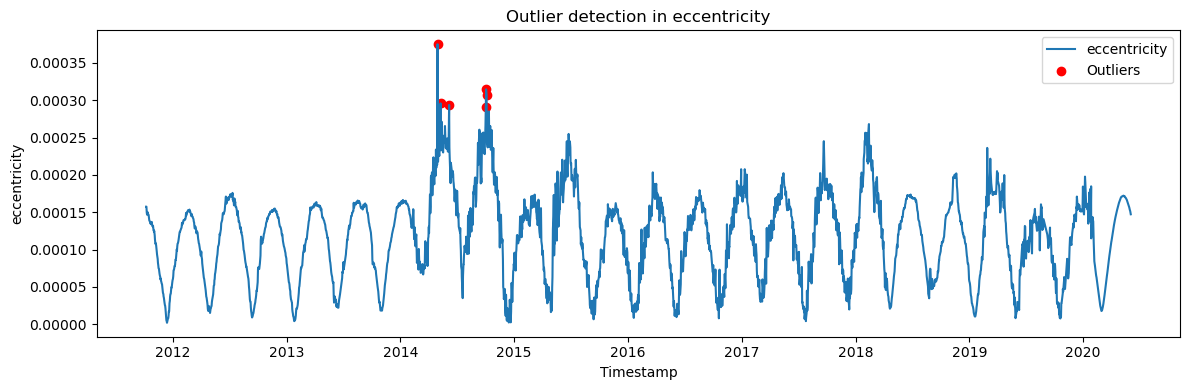

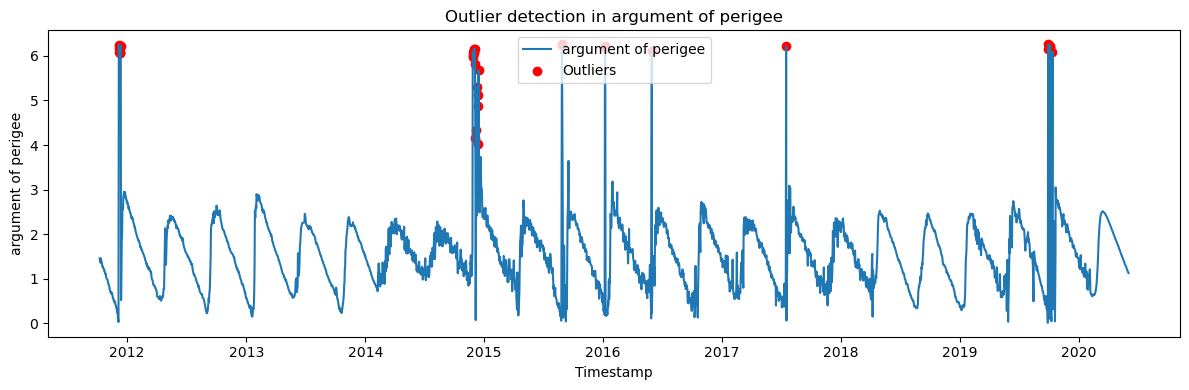

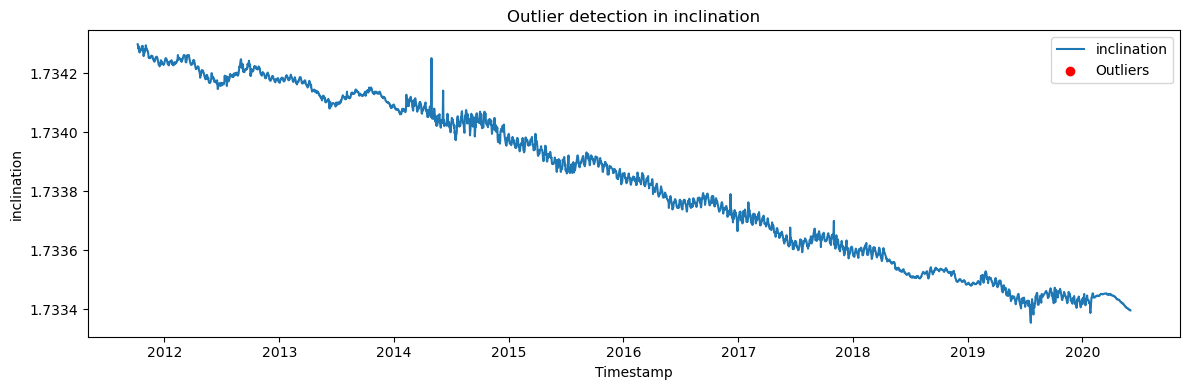

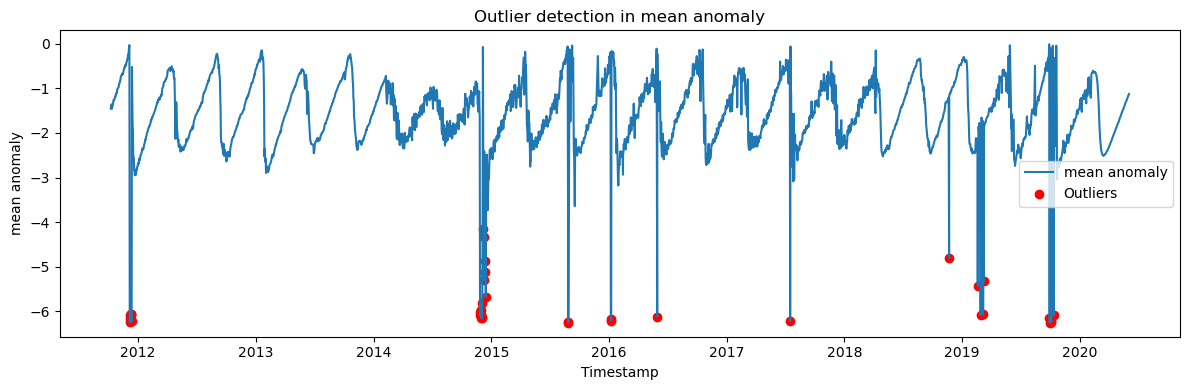

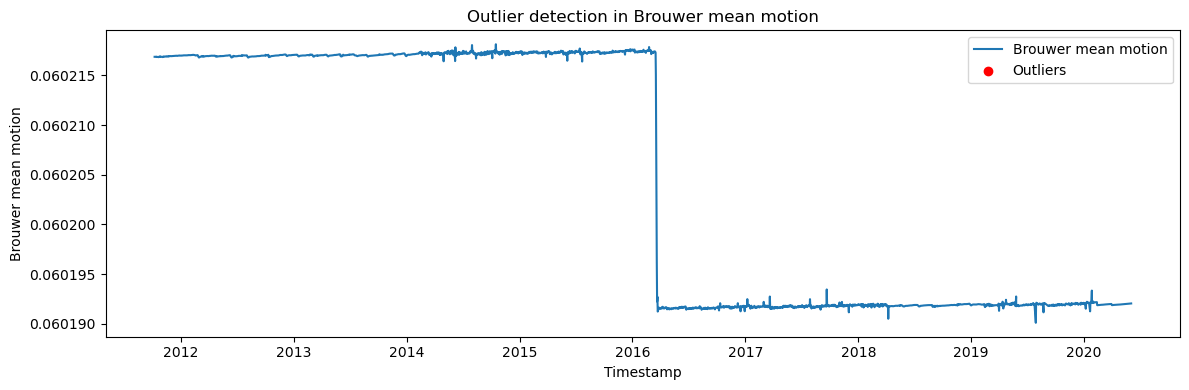

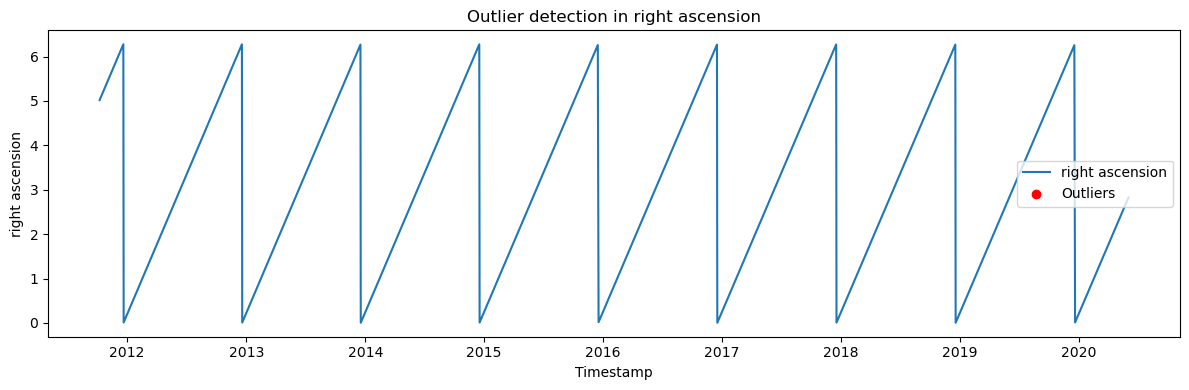

In [8]:
#Detecting outliers

def detect_outliers(df, threshold=3):
    z_scores = df.apply(zscore) 
    outliers = (z_scores.abs() > threshold)
    return outliers

def plot_outliers(df, outliers):
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(df.index, df[col], label=col)
        plt.scatter(df.index[outliers[col]], df[col][outliers[col]], color='red', label='Outliers')
        plt.title(f"Outlier detection in {col}")
        plt.legend()
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
outliers = detect_outliers(orb_df)
plot_outliers(orb_df, outliers)


Descriptive Statistics:
       eccentricity  argument of perigee  inclination  mean anomaly  \
count   2998.000000          2998.000000  2998.000000   2998.000000   
mean       0.000118             1.562484     1.733842     -1.566304   
std        0.000058             0.806231     0.000276      0.822871   
min        0.000002             0.014502     1.733355     -6.256930   
25%        0.000073             0.999030     1.733589     -2.093253   
50%        0.000125             1.543238     1.733850     -1.541934   
75%        0.000158             2.092170     1.734109     -0.996536   
max        0.000375             6.259006     1.734299     -0.012350   

       Brouwer mean motion  right ascension  
count          2998.000000      2998.000000  
mean              0.060205         3.085059  
std               0.000013         1.841693  
min               0.060190         0.002562  
25%               0.060192         1.479528  
50%               0.060217         2.992357  
75%          

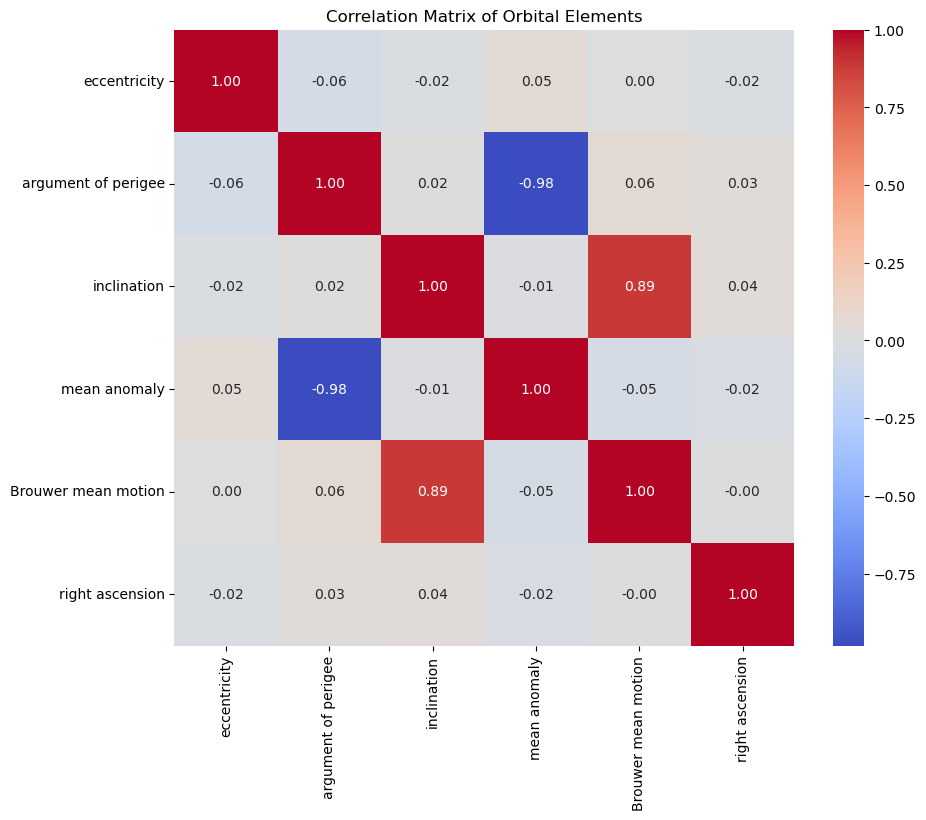

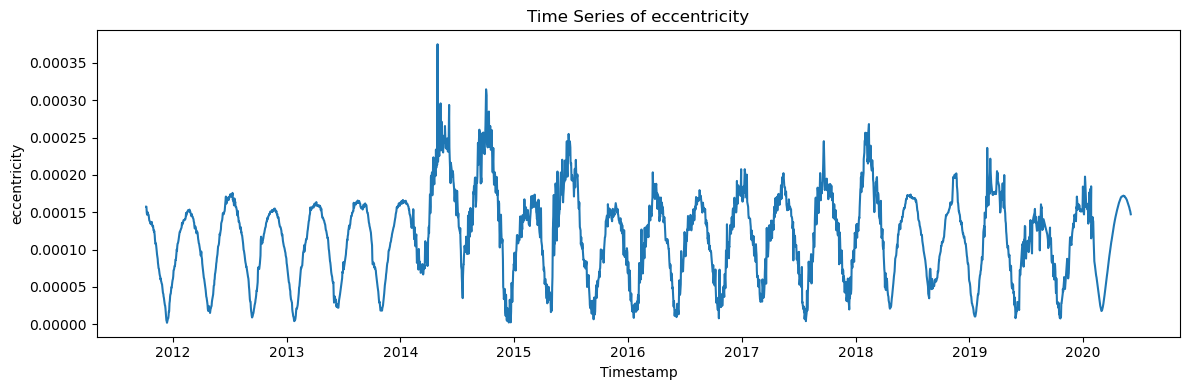

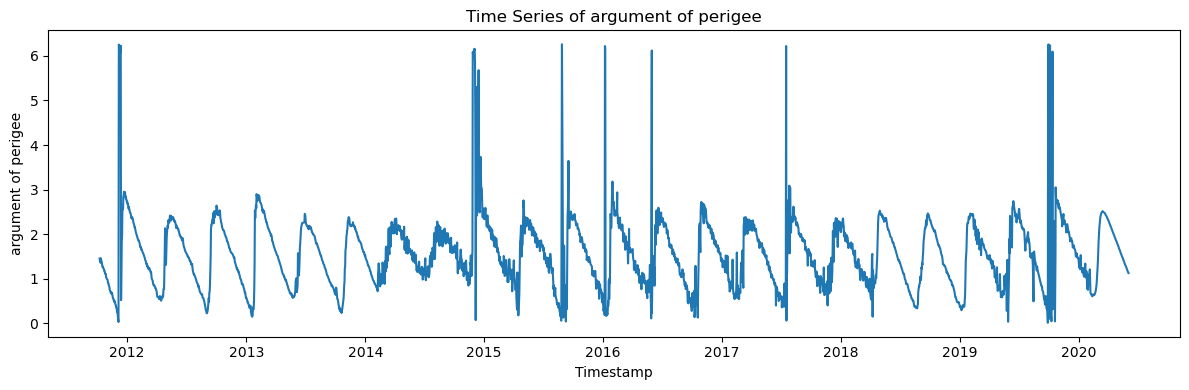

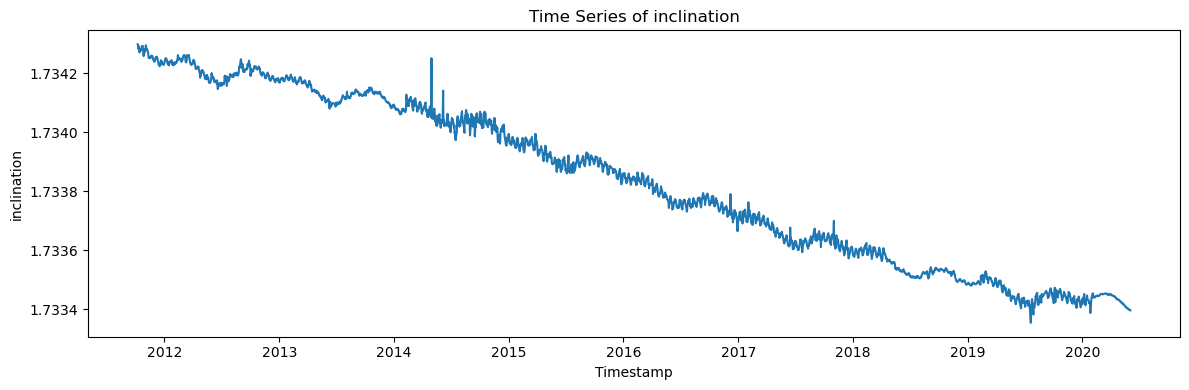

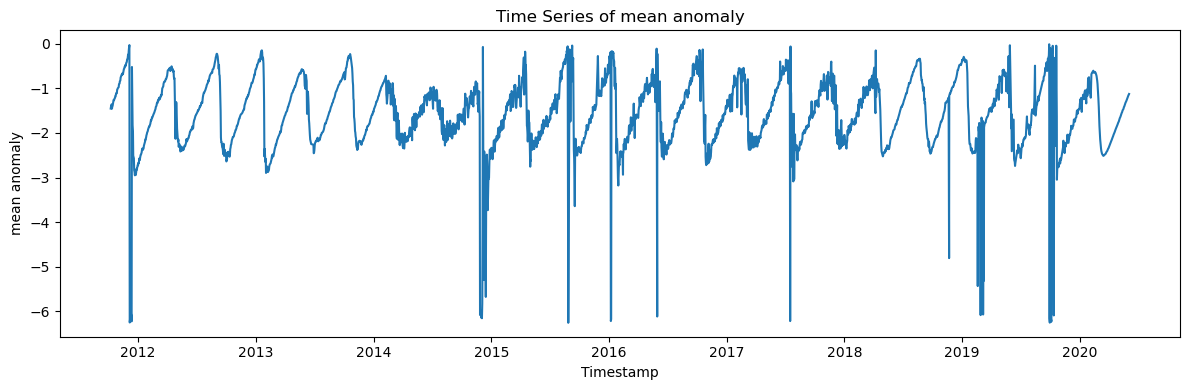

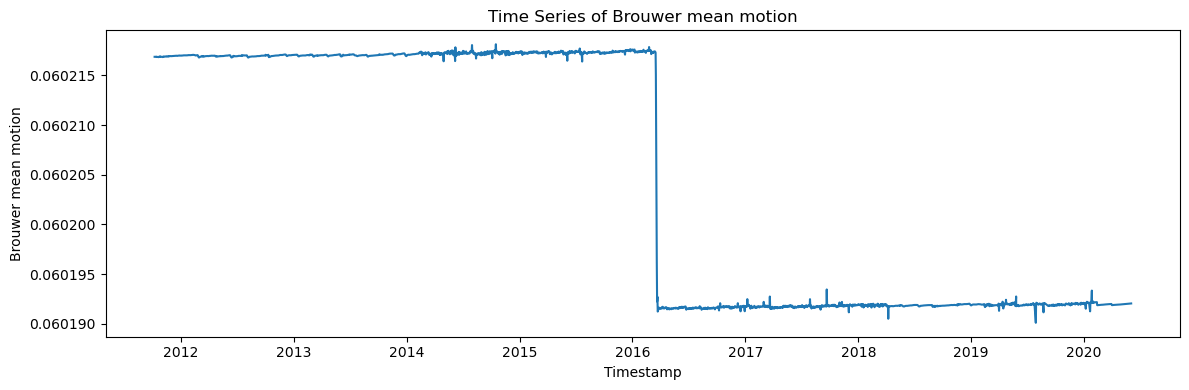

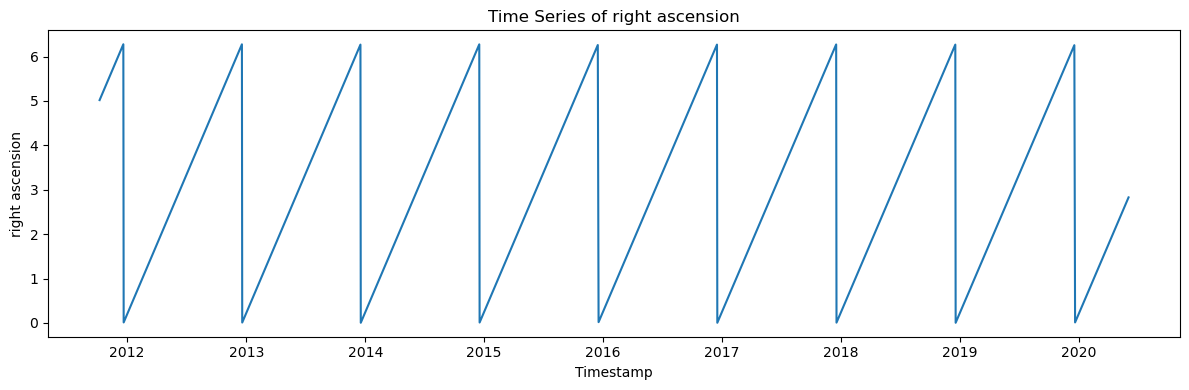

In [9]:
# EDA for orbital elements

def exploratory_analysis(df):
    print("\nDescriptive Statistics:")
    print(df.describe())

    print("\nNull Values:")
    print(df.isnull().sum())

    print("\nCorrelation Matrix:")
    corr = df.corr()
    print(corr)

    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Orbital Elements")
    plt.show()

    # Time series plot
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        sns.lineplot(x=df.index, y=df[col])
        plt.title(f"Time Series of {col}")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
exploratory_analysis(orb_df)

<Figure size 1000x400 with 0 Axes>

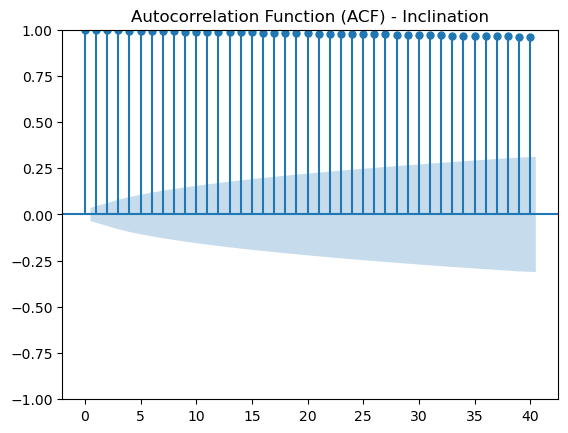

<Figure size 1000x400 with 0 Axes>

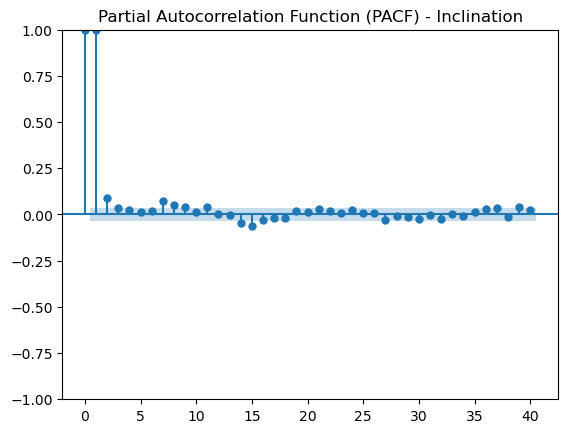


--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic     : -0.252252
p-value           : 0.932000
Critical Values   :
   1%: -3.4325
   5%: -2.8625
   10%: -2.5673

 The series is NOT stationary .


In [10]:
# EDA for inclination

series = orb_df['inclination'].dropna()

# ACF plot
plt.figure(figsize=(10, 4))
plot_acf(series, lags=40)
plt.title('Autocorrelation Function (ACF) - Inclination')
plt.show()

# PACF plot
plt.figure(figsize=(10, 4))
plot_pacf(series, lags=40, method='ywm') 
plt.title('Partial Autocorrelation Function (PACF) - Inclination')
plt.show()

# ADF Test
result = adfuller(series)
print('\n--- Augmented Dickey-Fuller (ADF) Test ---')
print(f"ADF Statistic     : {result[0]:.6f}")
print(f"p-value           : {result[1]:.6f}")
print(f"Critical Values   :")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
if result[1] < 0.05:
    print("\n The series is stationary .")
else:
    print("\n The series is NOT stationary .")


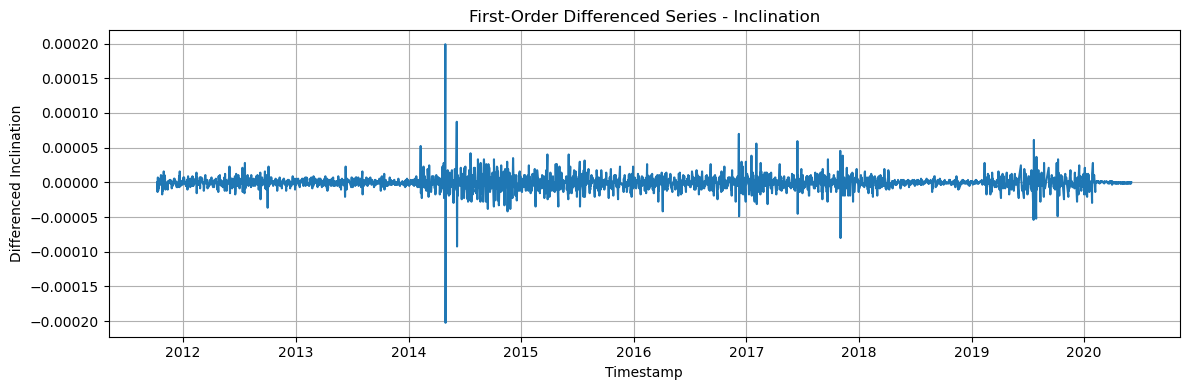


 ADF Test After Differencing 
ADF Statistic     : -14.063248
p-value           : 0.000000
Critical Values   :
   1%: -3.4325
   5%: -2.8625
   10%: -2.5673

 The differenced series is stationary .


In [11]:
# First-order differencing

series = orb_df['inclination'].dropna()
diff_series = series.diff().dropna()

# Plotting the differenced series
plt.figure(figsize=(12, 4))
plt.plot(diff_series)
plt.title('First-Order Differenced Series - Inclination')
plt.xlabel('Timestamp')
plt.ylabel('Differenced Inclination')
plt.grid(True)
plt.tight_layout()
plt.show()

# ADF Test =
print('\n ADF Test After Differencing ')
result = adfuller(diff_series)
print(f"ADF Statistic     : {result[0]:.6f}")
print(f"p-value           : {result[1]:.6f}")
print(f"Critical Values   :")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
if result[1] < 0.05:
    print("\n The differenced series is stationary .")
else:
    print("\n The differenced series is still not stationary.")


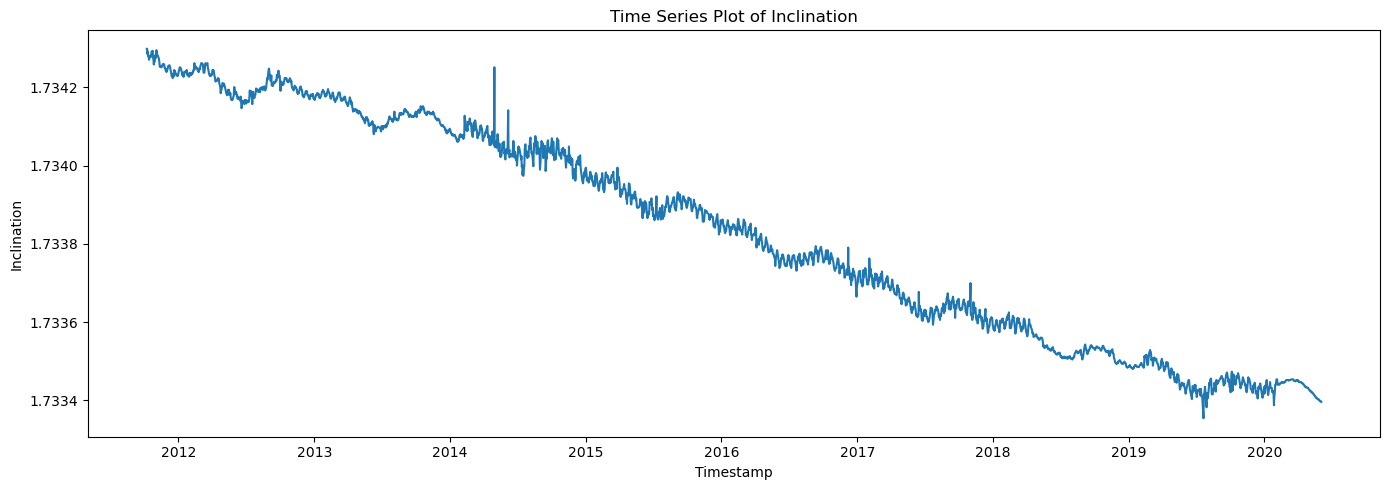

In [12]:
# Plotting the time series to observe trend

def plot_inclination_trend(df):
    plt.figure(figsize=(14, 5))
    sns.lineplot(x=df.index, y=df['inclination'])
    plt.title("Time Series Plot of Inclination")
    plt.xlabel("Timestamp")
    plt.ylabel("Inclination")
    plt.tight_layout()
    plt.show()
plot_inclination_trend(orb_df)


In [10]:
# Fill missing values
orb_df['inclination'] = orb_df['inclination'].ffill()

In [13]:
# Train test split for "mean anomaly" 
train_size = int(len(orb_df) * 0.8)
train_data = orb_df['mean anomaly'][:train_size]
test_data = orb_df['mean anomaly'][train_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (2398,)
Test data shape: (600,)


In [14]:
# Feature engineering function for inclination
def create_features(df, target_col='inclination', lags=30):
    if isinstance(df, pd.Series):
        df = df.to_frame(name=target_col)    
    df = df.copy() 
    # temporal features
    df['dayofyear'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    
    # lag features
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    df = df.dropna()    
    return df

In [15]:
# Create features 
target_col = 'target' 
train_features = create_features(train_data, target_col)
test_features = create_features(test_data, target_col)

X_train = train_features.drop(columns=[target_col])
y_train = train_features[target_col]
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
# model setup 
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Cross Validation 
tscv = TimeSeriesSplit(n_splits=3)

In [17]:
# Grid Search 
print("Starting Grid Search...")
grid_search = GridSearchCV(estimator=xgb_model,
                         param_grid=param_grid,
                         cv=tscv,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1,
                         verbose=1)
grid_search.fit(X_train_scaled, y_train)

# --- Get best model ---
best_xgb = grid_search.best_estimator_
print("\nBest parameters:", grid_search.best_params_)


Starting Grid Search...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [18]:
# Train final model 
best_xgb.fit(X_train_scaled, y_train,
            eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
            verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
# slicing the test data to match the shifted length
test_features = create_features(test_data, target_col)
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

In [21]:
#  predictions for the full test set
test_predictions = best_xgb.predict(X_test_scaled)


In [22]:
#Calculate RMSE 
train_predictions = best_xgb.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"\nTrain RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train RMSE: 0.3650
Test RMSE: 0.6117


In [23]:
print(len(test_data))
print(len(test_predictions))

600
570


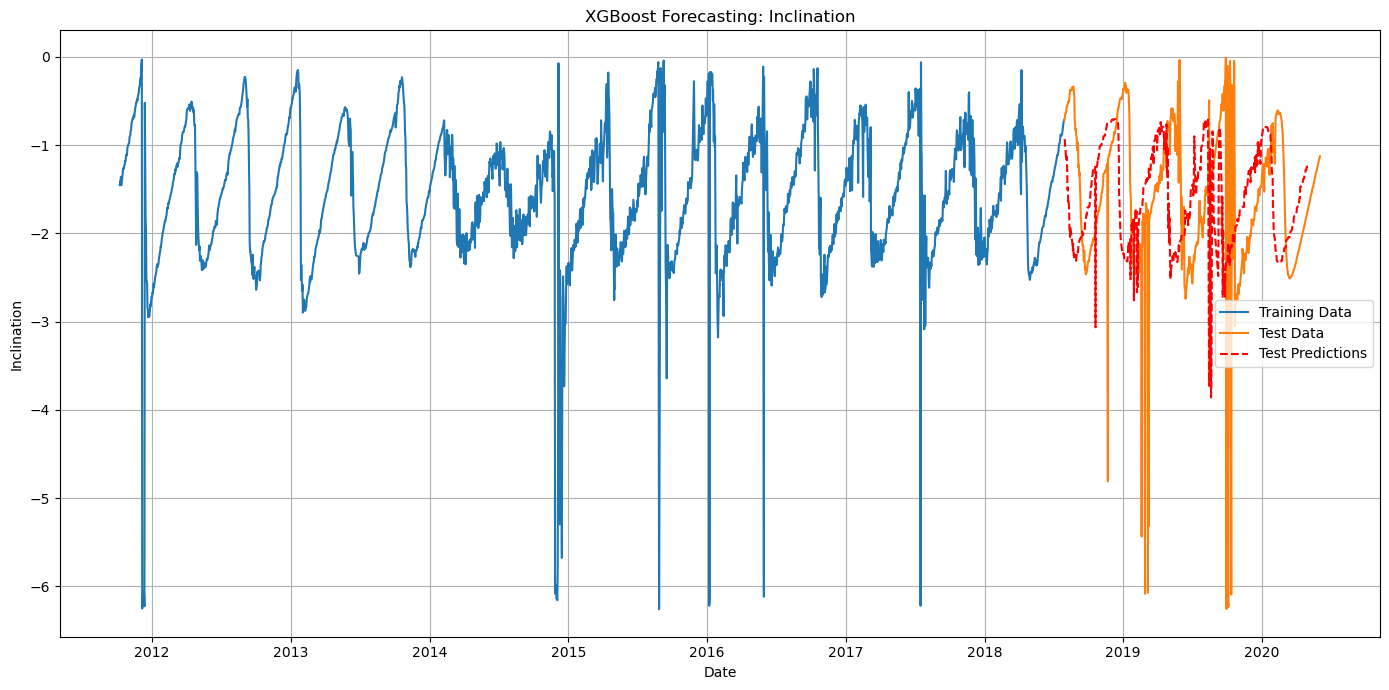

In [24]:
#  Plotting prediction vs observed for "inclination"
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Test Predictions', color='red', linestyle='--')  # Slice to match test predictions
plt.title("XGBoost Forecasting: Inclination")
plt.xlabel("Date")
plt.ylabel("Inclination")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


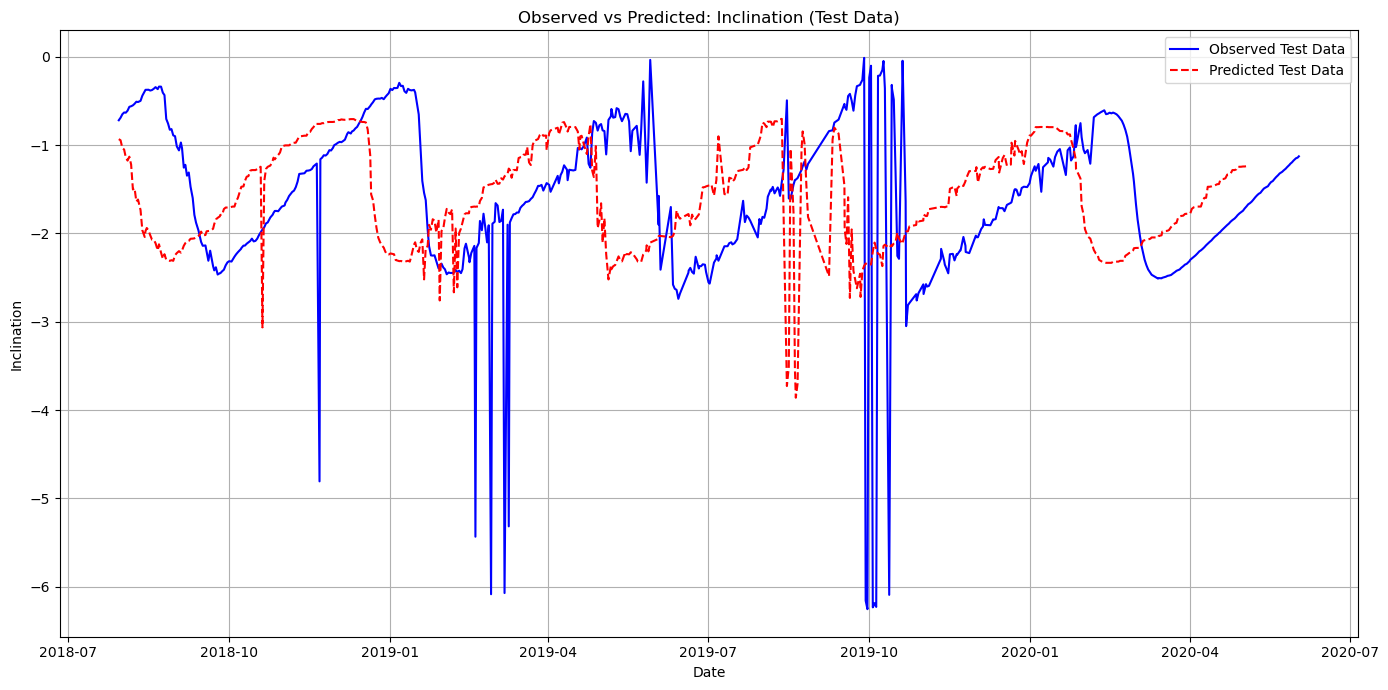

In [25]:
# Plotting only the observed vs predicted for "inclination" test data
plt.figure(figsize=(14, 7))

# observed values
plt.plot(test_data.index, test_data, label='Observed Test Data', color='blue')

# predicted values
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Predicted Test Data', color='red', linestyle='--')

plt.title("Observed vs Predicted: Inclination (Test Data)")
plt.xlabel("Date")
plt.ylabel("Inclination")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


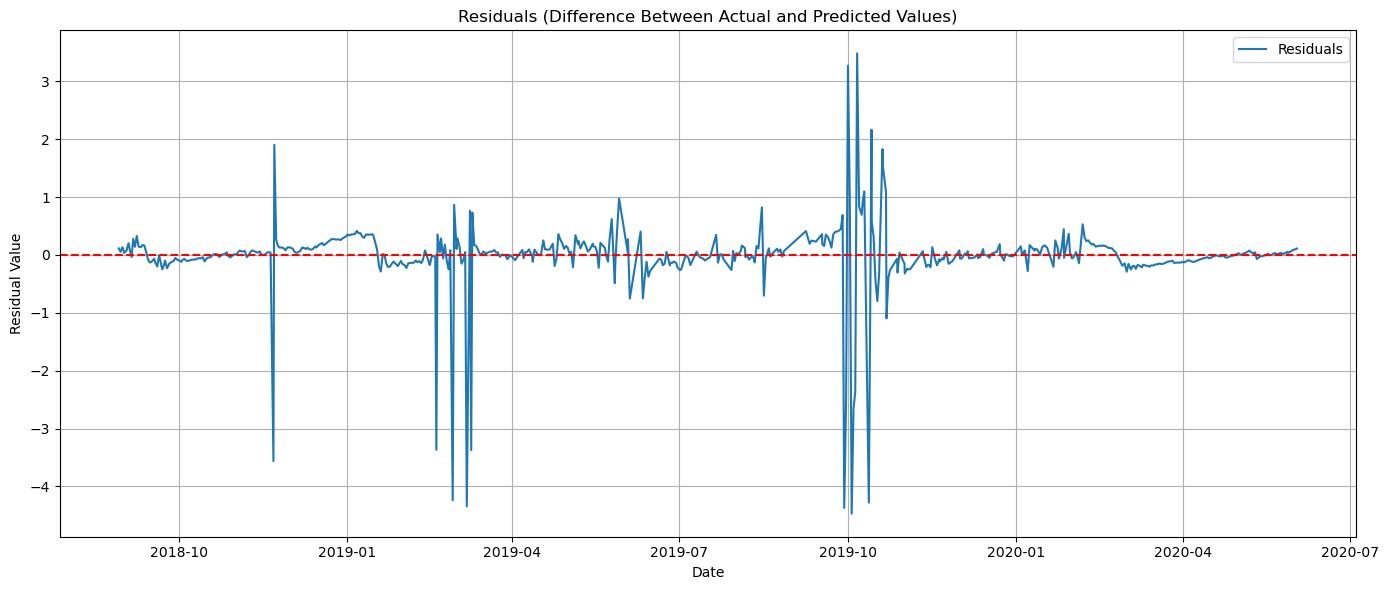

In [26]:
# Calculate residuals for predictions 
residuals = y_test - test_predictions

#Plotting Residuals
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, residuals, label='Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals (Difference Between Actual and Predicted Values)')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
# Absolute Residuals ---
abs_residuals = np.abs(residuals)

# Threshold for Manoeuvre Detection 
threshold_std = abs_residuals.mean() + 2 * abs_residuals.std()
threshold = threshold_std
print(f"Threshold value used: {threshold:.8f}")

Threshold value used: 1.36641795


In [28]:
# Detecting Manoeuvres using residuals
detected_manoeuvres = residuals[abs_residuals > threshold]
print(f"Number of detected manoeuvres: {len(detected_manoeuvres)}")

# Group detected points into events
detected_dates = detected_manoeuvres.index.tolist()
manoeuvre_events = []

if detected_dates:
    current_event = [detected_dates[0]]
    for i in range(1, len(detected_dates)):
        if (detected_dates[i] - current_event[-1]).days <= 2:
            current_event.append(detected_dates[i])
        else:
            manoeuvre_events.append({
                'start_time': current_event[0],
                'end_time': current_event[-1],
                'max_residual': abs_residuals[current_event].max()
            })
            current_event = [detected_dates[i]]
    manoeuvre_events.append({
        'start_time': current_event[0],
        'end_time': current_event[-1],
        'max_residual': abs_residuals[current_event].max()
    })
detected_df = pd.DataFrame(manoeuvre_events)
print("\nDetected Manoeuvre Events:")
print(detected_df)


Number of detected manoeuvres: 17

Detected Manoeuvre Events:
                  start_time                   end_time  max_residual
0 2018-11-21 14:43:00.704640 2018-11-22 02:11:04.862400      3.561612
1 2019-02-18 12:19:00.122304 2019-02-18 12:19:00.122304      3.366507
2 2019-02-27 10:23:19.895423 2019-02-27 10:23:19.895423      4.239900
3 2019-03-07 02:51:54.235872 2019-03-09 12:39:07.006751      4.343606
4 2019-09-29 01:14:47.618591 2019-10-06 02:11:19.830335      4.471435
5 2019-10-12 11:27:21.737951 2019-10-13 22:17:22.095743      4.279022
6 2019-10-19 22:50:53.714976 2019-10-20 02:19:53.716799      1.829246


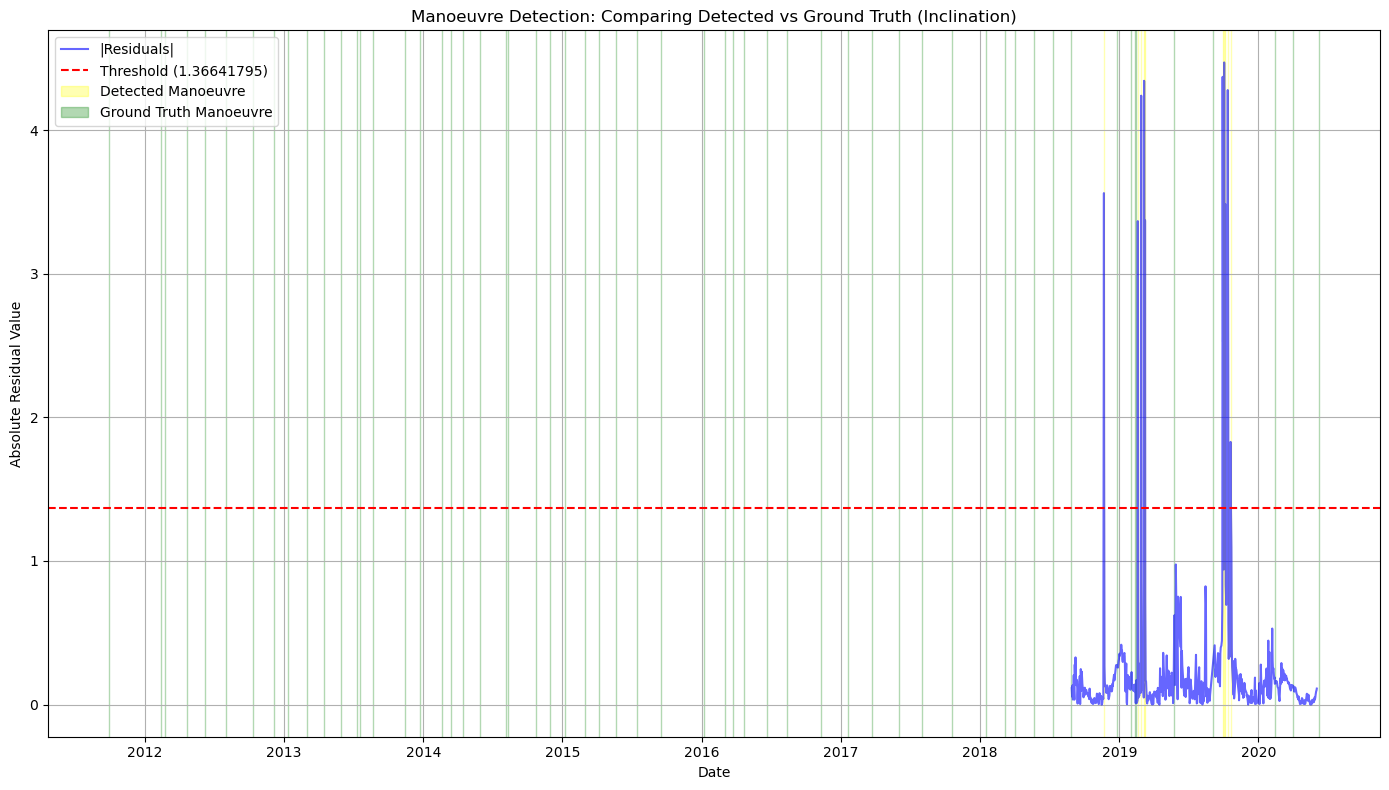


Detection Accuracy Metrics:
True Positives: 0
False Positives: 7
False Negatives: 58
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


In [37]:
# --- Step 8: Plot Detected Manoeuvres vs Ground Truth ---
plt.figure(figsize=(14, 8))

# Plot absolute residuals
plt.plot(abs_residuals.index, abs_residuals, label='|Residuals|', color='blue', alpha=0.6)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

# Mark detected manoeuvre events
for idx, event in enumerate(manoeuvre_events):
    plt.axvspan(event['start_time'], event['end_time'], 
                alpha=0.3, color='yellow', label='Detected Manoeuvre' if idx == 0 else '')

# Mark ground truth manoeuvres (assuming you have a ground truth DataFrame called man_df for inclination)
for idx, row in man_df.iterrows():
    plt.axvspan(row['start_time'], row['end_time'], 
                alpha=0.3, color='green', label='Ground Truth Manoeuvre' if idx == 0 else '')

plt.title('Manoeuvre Detection: Comparing Detected vs Ground Truth (Inclination)')
plt.xlabel('Date')
plt.ylabel('Absolute Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Step 9: Calculate Detection Accuracy Metrics ---
def calculate_detection_accuracy(detected_df, ground_truth_df, tolerance_days=3):
    """
    Calculate how well detected manoeuvres align with ground truth manoeuvres.
    """
    true_positives = 0
    false_positives = 0

    # For each detected event, check if it overlaps or is close to ground truth
    for _, det_event in detected_df.iterrows():
        matched = False
        for _, gt_event in ground_truth_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break

        if matched:
            true_positives += 1
        else:
            false_positives += 1

    # False negatives: ground truth events not detected
    false_negatives = 0
    for _, gt_event in ground_truth_df.iterrows():
        matched = False
        for _, det_event in detected_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break

        if not matched:
            false_negatives += 1

    # Metrics
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }

# --- Step 10: Apply the Accuracy Evaluation ---
metrics = calculate_detection_accuracy(detected_df, man_df)

print("\nDetection Accuracy Metrics:")
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"False Negatives: {metrics['false_negatives']}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")


In [29]:
# summary tables

print("\n[ XGBoost ] Detected Manoeuvres:")
print(detected_df[['start_time', 'end_time', 'max_residual']])

print("\nGround Truth Manoeuvres:")
print(man_df[['start_time', 'end_time']])



[ XGBoost ] Detected Manoeuvres:
                  start_time                   end_time  max_residual
0 2018-11-21 14:43:00.704640 2018-11-22 02:11:04.862400      3.561612
1 2019-02-18 12:19:00.122304 2019-02-18 12:19:00.122304      3.366507
2 2019-02-27 10:23:19.895423 2019-02-27 10:23:19.895423      4.239900
3 2019-03-07 02:51:54.235872 2019-03-09 12:39:07.006751      4.343606
4 2019-09-29 01:14:47.618591 2019-10-06 02:11:19.830335      4.471435
5 2019-10-12 11:27:21.737951 2019-10-13 22:17:22.095743      4.279022
6 2019-10-19 22:50:53.714976 2019-10-20 02:19:53.716799      1.829246

Ground Truth Manoeuvres:
            start_time            end_time
0  2011-09-28 16:20:00 2011-09-28 16:20:00
1  2012-02-14 03:05:00 2012-02-14 03:05:00
2  2012-02-24 03:20:00 2012-02-24 03:20:00
3  2012-04-20 03:20:00 2012-04-20 03:20:00
4  2012-06-08 02:35:00 2012-06-08 02:35:00
5  2012-08-01 03:25:00 2012-08-01 03:25:00
6  2012-10-10 03:26:00 2012-10-10 03:26:00
7  2012-12-05 01:50:00 2012-12-05 01

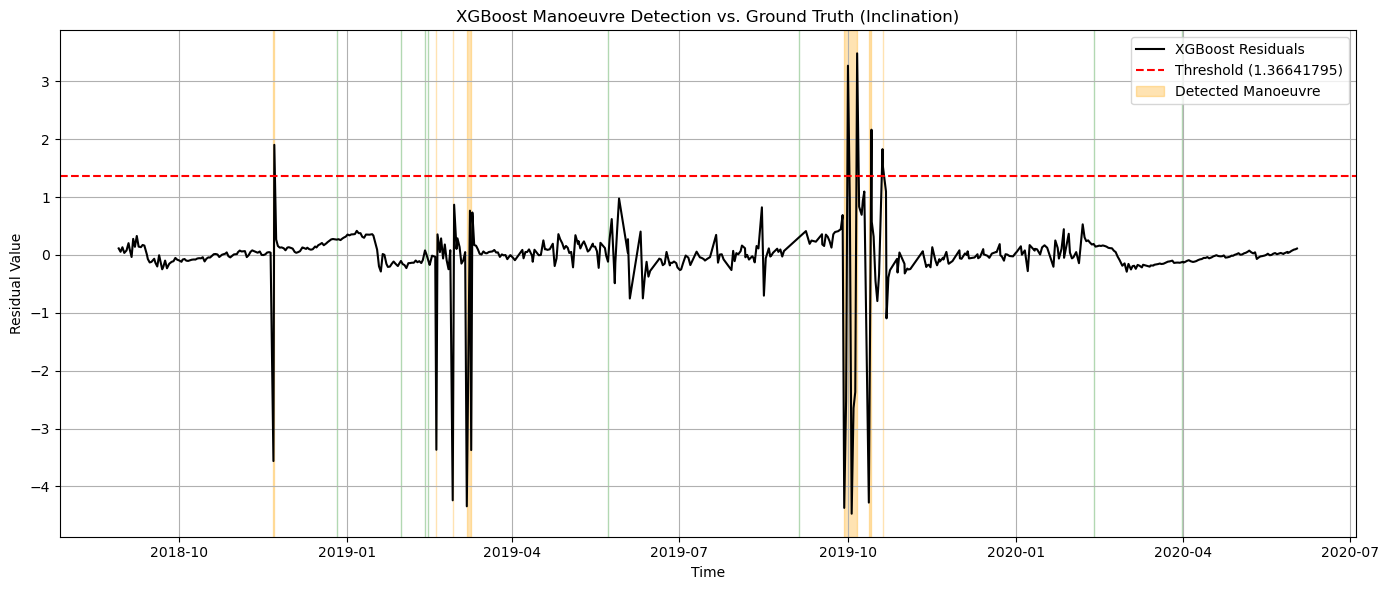

In [30]:
# Filter ground truth manoeuvres
man_df_filtered = man_df[
    (man_df['start_time'] >= residuals.index.min()) &
    (man_df['end_time'] <= residuals.index.max())
]
plt.figure(figsize=(14, 6))

# residuals
plt.plot(residuals.index, residuals.values, label='XGBoost Residuals', color='black')

# threshold
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

# detected manoeuvres 
if not detected_df.empty:
    for idx, row in detected_df.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='orange', alpha=0.3,
                    label='Detected Manoeuvre' if idx == 0 else "")

# ground truth manoeuvres
if not man_df_filtered.empty:
    for idx, row in man_df_filtered.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.3,
                    label='Ground Truth Manoeuvre' if idx == 0 else "")

plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.title('XGBoost Manoeuvre Detection vs. Ground Truth (Inclination)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


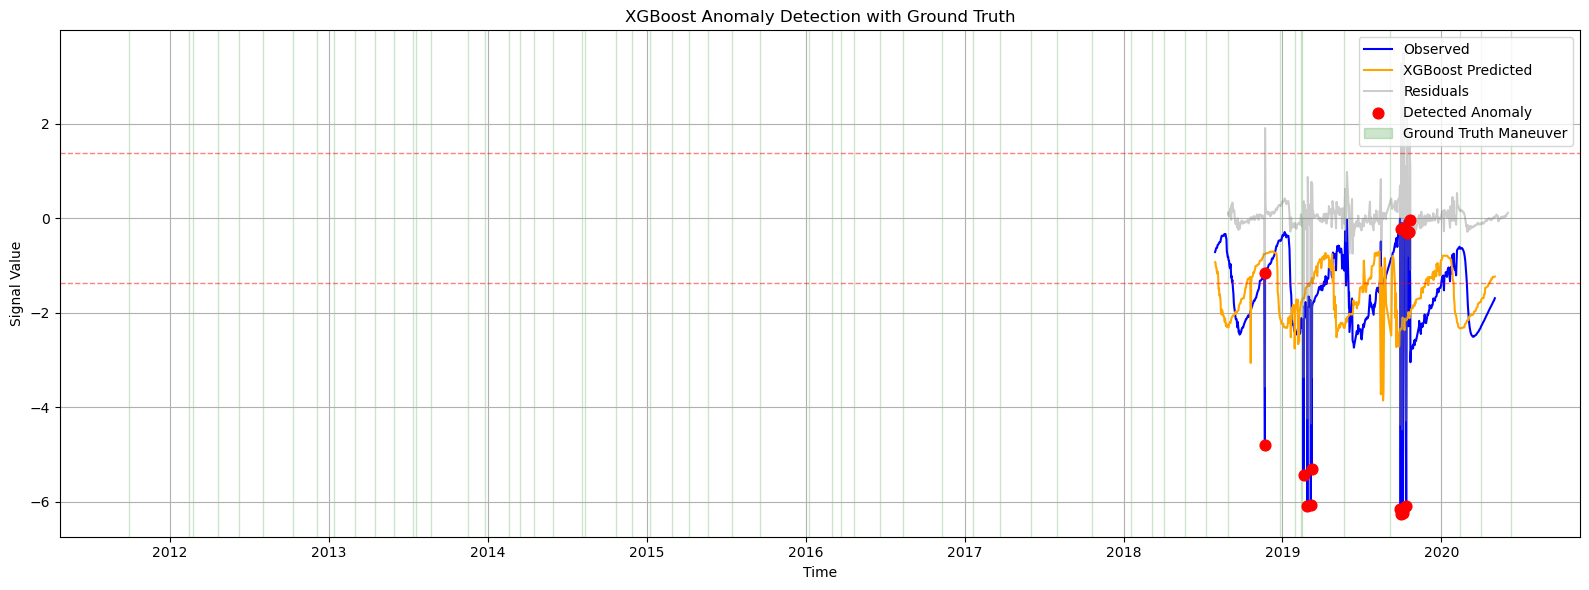

In [31]:
def detect_anomalies(residuals, threshold):
    anomaly_mask = residuals.abs() > threshold
    return residuals[anomaly_mask]

def plot_all_in_one_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        print(f"Warning: Length mismatch. Observed: {len(observed)}, Predicted: {len(predicted)}")
        min_len = min(len(observed), len(predicted))
        observed = observed[:min_len]
        predicted = predicted[:min_len]
        residuals = residuals[:min_len]
    predicted = pd.Series(predicted, index=observed.index)
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[anomalies.index.isin(observed.index)]
    fig, ax = plt.subplots(figsize=(16, 6))

    # Observed and Predicted
    ax.plot(observed.index, observed.values, label='Observed', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted', color='orange', linewidth=1.5)

    # residuals
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.4, label='Residuals')

    # anomalies
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # threshold 
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=-threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)

    # Ground Truth Maneuvers
    for idx, row in man_df.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == 0 else "")

    ax.set_title("XGBoost Anomaly Detection with Ground Truth")
    ax.set_xlabel("Time")
    ax.set_ylabel("Signal Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
plot_all_in_one_xgboost(test_data, test_predictions, residuals, threshold, man_df)


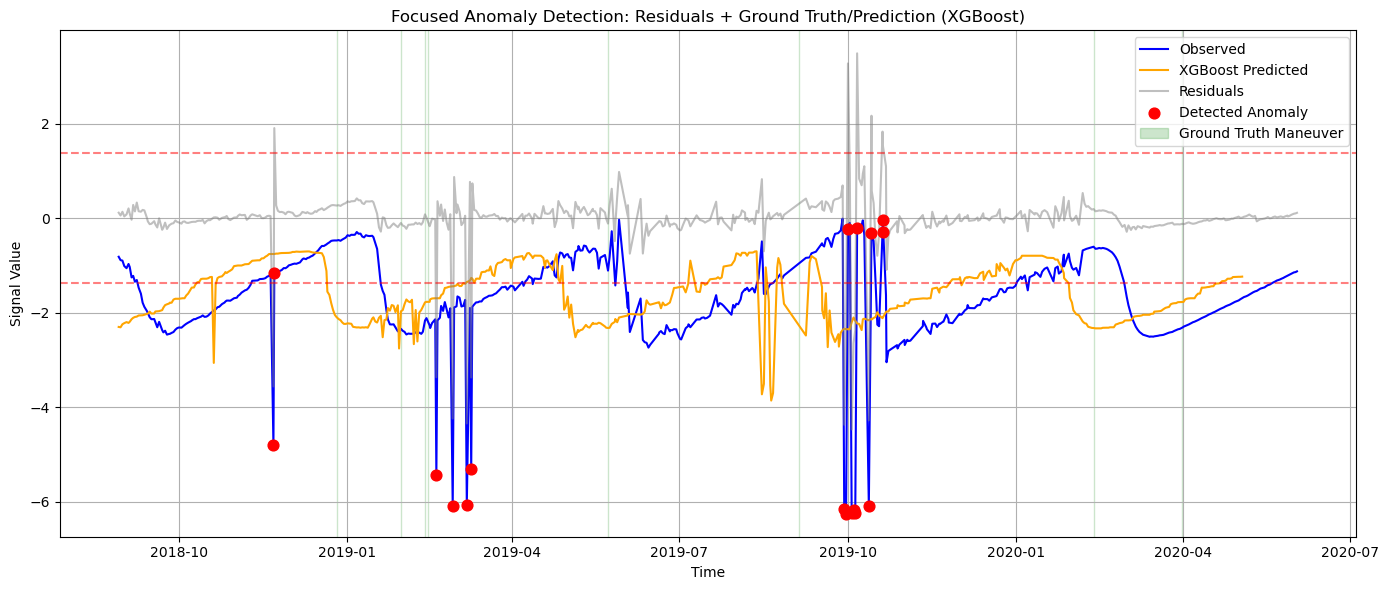

In [32]:
def detect_anomalies(residuals, threshold):
    anomaly_mask = residuals.abs() > threshold
    return residuals[anomaly_mask]

def plot_focused_anomalies_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        predicted = pd.Series(predicted, index=observed.index[:len(predicted)])
    valid_times = residuals.dropna().index
    valid_man = man_df[
        (man_df['end_time'] >= valid_times.min()) &
        (man_df['start_time'] <= valid_times.max())
    ]
    #start and end time 
    plot_start = max(valid_times.min(), predicted.dropna().index.min())
    plot_end = max(valid_times.max(), predicted.dropna().index.max())
    observed = observed[(observed.index >= plot_start) & (observed.index <= plot_end)]
    predicted = predicted[(predicted.index >= plot_start) & (predicted.index <= plot_end)]
    residuals = residuals[(residuals.index >= plot_start) & (residuals.index <= plot_end)]
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[(anomalies.index >= plot_start) & (anomalies.index <= plot_end)]
    valid_man = valid_man[
        (valid_man['start_time'] <= plot_end) &
        (valid_man['end_time'] >= plot_start)
    ]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))

    # Observed and Predicted 
    ax.plot(observed.index, observed.values, label='Observed', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted', color='orange', linewidth=1.5)
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.5, label='Residuals')

    # Detected anomalies
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # Residual threshold
    ax.axhline(threshold, linestyle='--', color='red', alpha=0.5)
    ax.axhline(-threshold, linestyle='--', color='red', alpha=0.5)

    # Ground truth 
    for idx, row in valid_man.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == valid_man.index[0] else "")
    ax.set_title("Focused Anomaly Detection: Residuals + Ground Truth/Prediction (XGBoost)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Signal Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
plot_focused_anomalies_xgboost(test_data, test_predictions, residuals, threshold, man_df)
